In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [17]:
data = pd.read_csv('data.csv')

In [18]:
data['rating'].mean()

np.float64(6.139848874726681)

In [19]:
data

,id,title,year,runtimeMinutes,rating,votes,genres
0,tt0000009,Miss Jerry,1894,45.0,5.3,231,Romance
1,tt2210499,Birmingham,1896,61.0,3.4,30,Documentary
2,tt0000147,The Corbett-Fitzsimmons Fight,1897,100.0,5.3,601,"Documentary,News,Sport"
3,tt0229676,Reproduction of the Corbett and Fitzsimmons Fight,1897,NaN,4.1,71,"Documentary,News,Sport"
4,tt0138342,O Campo Grande,1898,NaN,2.7,17,Documentary
...,...,...,...,...,...,...,...
300011,tt9204444,Dad Genes,2026,65.0,6.9,13,Documentary
300012,tt9213874,Breeder,2026,97.0,7.2,9,"Horror,Thriller"
300013,tt9522946,Harvest,2026,118.0,9.2,2932,Drama
300014,tt9661164,No Ordinary Heist,2026,99.0,5.6,693,"Crime,Drama,Thriller"


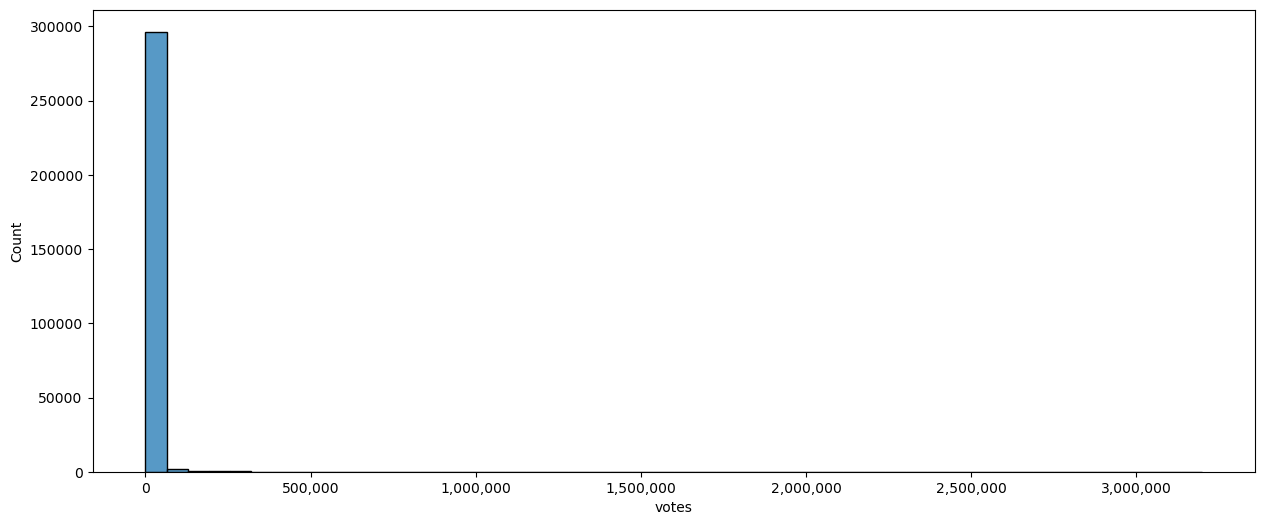

In [22]:
plt.figure(figsize=(15,6))
sns.histplot(data['votes'], bins=50, kde=False)
ax = plt.gca()

# Format with commas (e.g., 1,000,000)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

In [23]:
C = data['rating'].mean()

m = data['votes'].quantile(0.90)

data['score'] = (
    (data['rating'] * data['votes'] + m * C)
    / (data['votes'] + m)
).round(2)

In [24]:
data

,id,title,year,runtimeMinutes,rating,votes,genres,score
0,tt0000009,Miss Jerry,1894,45.0,5.3,231,Romance,6.05
1,tt2210499,Birmingham,1896,61.0,3.4,30,Documentary,6.10
2,tt0000147,The Corbett-Fitzsimmons Fight,1897,100.0,5.3,601,"Documentary,News,Sport",5.94
3,tt0229676,Reproduction of the Corbett and Fitzsimmons Fight,1897,NaN,4.1,71,"Documentary,News,Sport",6.07
4,tt0138342,O Campo Grande,1898,NaN,2.7,17,Documentary,6.11
...,...,...,...,...,...,...,...,...
300011,tt9204444,Dad Genes,2026,65.0,6.9,13,Documentary,6.14
300012,tt9213874,Breeder,2026,97.0,7.2,9,"Horror,Thriller",6.14
300013,tt9522946,Harvest,2026,118.0,9.2,2932,Drama,7.98
300014,tt9661164,No Ordinary Heist,2026,99.0,5.6,693,"Crime,Drama,Thriller",6.00


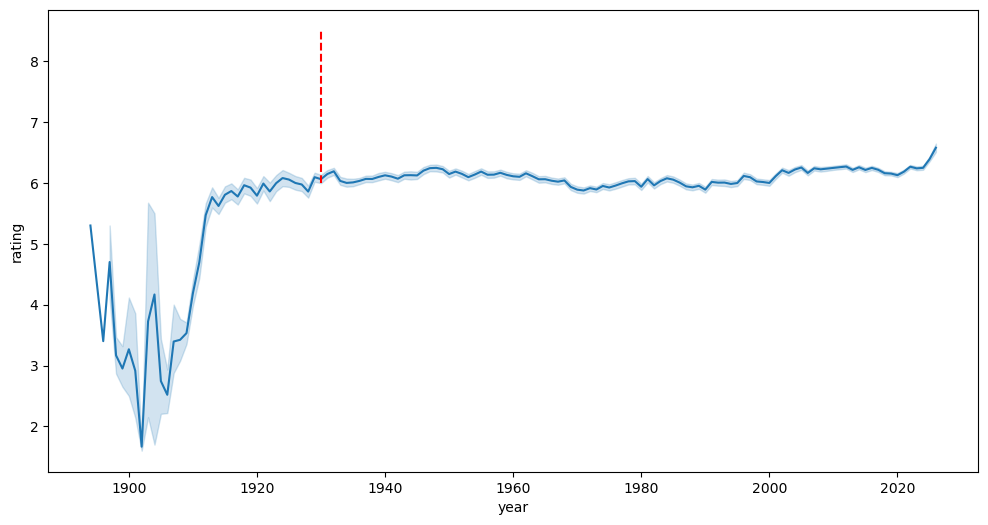

In [27]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='year', y='rating', marker=None)
plt.vlines(x=1930, ymin=6, ymax=8.5, colors='r', linestyles='--', label='1930')

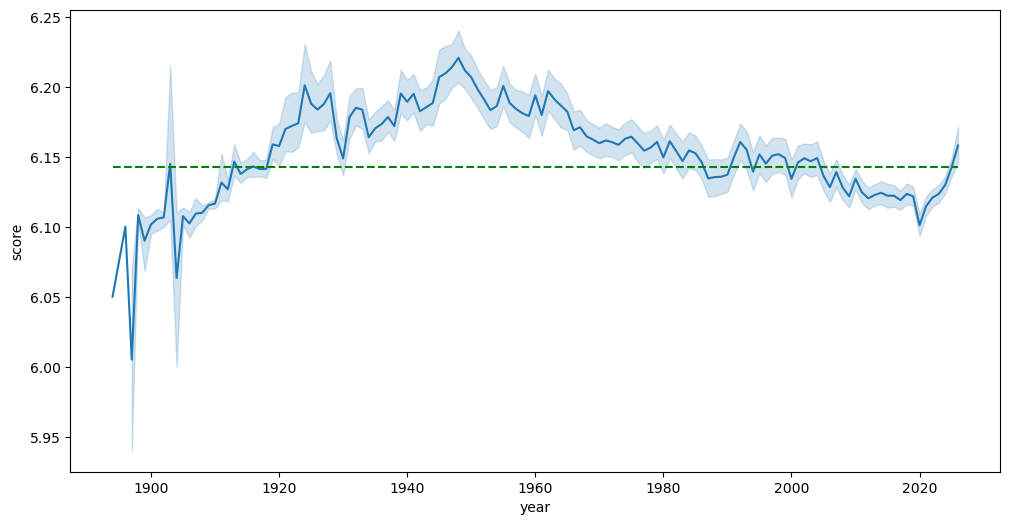

In [28]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='year', y='score', marker=None)
plt.hlines(y=data['score'].mean(), xmin=data['year'].min(), xmax=data['year'].max(), colors='g', linestyles='--', label='Mean Score')
# plt.vlines(x=1930, ymin=6, ymax=8.5, colors='r', linestyles='--', label='1930')

<Axes: xlabel='year', ylabel='rating'>

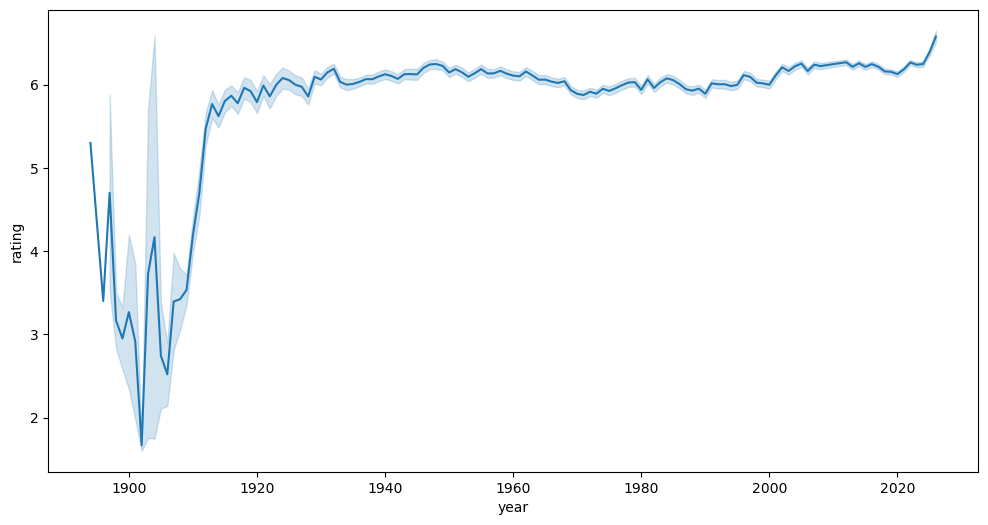

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x='year', y='rating', errorbar=('se', 1.96), marker=None)

In [31]:
data['votes'].max()

3199370

Text(0, 0.5, 'Number of Movies')

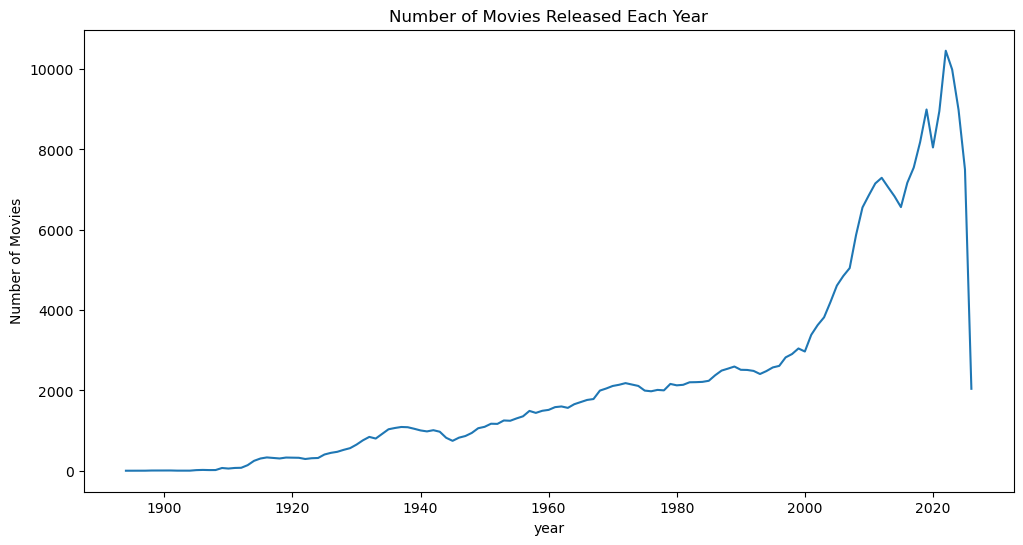

In [36]:
tmp = data['year'].value_counts().sort_index()
# sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(x=tmp.index, y=tmp.values)
plt.title('Number of Movies Released Each Year')
plt.xlabel('year')
plt.ylabel('Number of Movies')